## Dataset Overview

This dataset is used for predicting the bankruptcy of Polish companies based on financial indicators and ratios. Bankrupt companies were analyzed during the period **2000–2012**, while companies that remained operational were evaluated from **2007–2013**.

The dataset contains multiple forecasting scenarios and a collection of financial features that can be used to build and evaluate bankruptcy prediction models.

For additional details about the dataset structure, forecasting periods, feature definitions, and target variable, refer to the **`dataset_description.md`** and **`data_dictionary.md`** files located in the **`references/`** directory.


In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [30]:
df = pd.read_csv("../data/raw/Bankruptcy Master Dataset.csv",low_memory=False, index_col="id", dtype="float", na_values="?")
df[["Class","Year"]]=df[["Class","Year"]].astype("int")
df.index=df.index.astype("int")
df = df.reset_index(drop=True)
df.head()

,Year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Class
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [31]:
# Checking the distribution of tyhe positive and negative classes
df["Class"].value_counts(normalize=True)

Class
0    0.951826
1    0.048174
Name: proportion, dtype: float64

### keep in mind the the feature `class` is our target variable

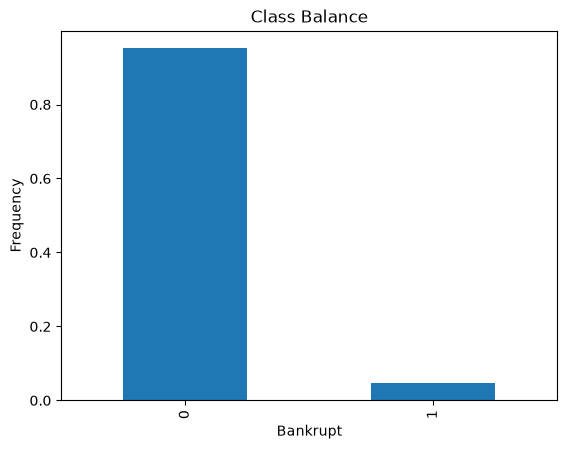

In [32]:
df["Class"].value_counts(normalize=True).plot(
    kind="bar",
    xlabel="Bankrupt",
    ylabel="Frequency",
    title="Class Balance"
);
plt.savefig("../reports/figures/class_balance.png", dpi=150)

## Class `Target Variable` Distribution Analysis

From the visualization above, we can observe that the dataset has a significant imbalance between the positive and negative classes. The number of non-bankrupt companies is much higher than the number of bankrupt companies.

This class imbalance is an important factor to consider when evaluating the performance of classification models. Using **accuracy** alone may not provide a reliable measure, as a model could achieve a high accuracy by simply predicting the majority class while failing to identify bankrupt companies.

Therefore, evaluation metrics that focus on the performance of each class are more suitable for this problem. Metrics such as **precision**, **recall**, **F1-score**, and the **ROC-AUC score** will provide a better understanding of the model's ability to correctly identify bankrupt companies while minimizing false predictions.


## Feature Analysis

Feature **X27 (Profit on operating activities / Financial expenses)** measures the company's ability to cover financial expenses using operating profits. This feature may indicate financial stability, where higher values could suggest lower bankruptcy risk.


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    43405 non-null  int64  
 1   X1      43397 non-null  float64
 2   X2      43397 non-null  float64
 3   X3      43397 non-null  float64
 4   X4      43271 non-null  float64
 5   X5      43316 non-null  float64
 6   X6      43397 non-null  float64
 7   X7      43397 non-null  float64
 8   X8      43311 non-null  float64
 9   X9      43396 non-null  float64
 10  X10     43397 non-null  float64
 11  X11     43361 non-null  float64
 12  X12     43271 non-null  float64
 13  X13     43278 non-null  float64
 14  X14     43397 non-null  float64
 15  X15     43369 non-null  float64
 16  X16     43310 non-null  float64
 17  X17     43311 non-null  float64
 18  X18     43397 non-null  float64
 19  X19     43277 non-null  float64
 20  X20     43278 non-null  float64
 21  X21     37551 non-null  float64
 22  X22     4

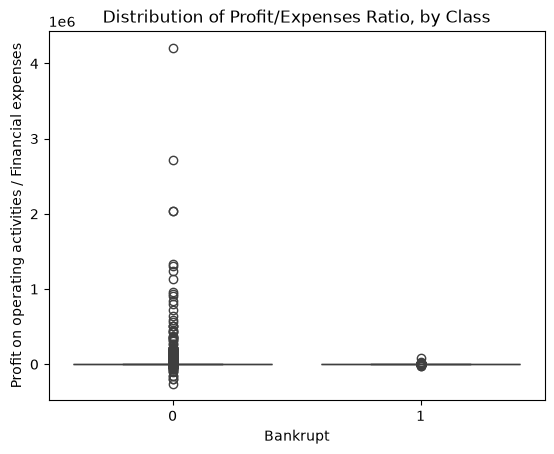

In [34]:
sns.boxplot(x="Class", y="X27",data=df);
plt.xlabel("Bankrupt")
plt.ylabel("Profit on operating activities / Financial expenses")
plt.title("Distribution of Profit/Expenses Ratio, by Class");

In [35]:
df["X27"].describe().apply("{0:,.0f}".format)

count       40,641
mean         1,108
std         35,015
min       -259,000
25%              0
50%              1
75%              5
max      4,210,000
Name: X27, dtype: str

Upon closer examination of the statistical summary, we observe that the median is 1, while the mean is 1108. This substantial difference between the mean and median strongly suggests that the dataset is highly right-skewed. Such skewness indicates the presence of extreme values or outliers that are pulling the mean upward. Addressing this skewness is important, as it may affect the performance and assumptions of certain statistical analyses and machine learning models.


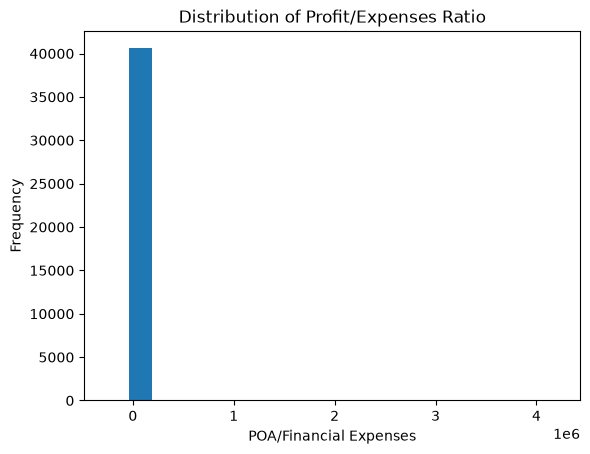

In [36]:
plt.hist(df["X27"], bins=20)
plt.xlabel("POA/Financial Expenses")
plt.ylabel("Frequency")
plt.title("Distribution of Profit/Expenses Ratio");

In [37]:
# POA/Financial expenses outliers
low,high = df["X27"].quantile([0.1,0.9])
df = df[df["X27"].between(low,high)]
df = df.reset_index(drop=True)
df.head()

,Year,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X56,X57,X58,X59,X60,X61,X62,X63,X64,Class
0,1,0.200550,0.379510,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.13890,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.6580,4.4158,7.4277,0
1,1,0.081483,0.307340,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.05710,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.4350,4.2228,5.5497,0
2,1,0.187320,0.613230,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.15590,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.2100,2.8692,7.8980,0
3,1,0.111090,0.647440,0.28971,1.4705,2.5349,0.00000,0.111090,0.54454,1.73480,...,0.605900,0.31510,0.40871,0.000000,6.3222,2.9098,129.5500,2.8173,18.3520,0
4,1,0.532320,0.027059,0.70554,53.9540,299.5800,0.00000,0.652400,35.95700,0.65273,...,0.086730,0.54713,0.49521,0.013194,9.1300,82.0500,7.4503,48.9910,2.3217,0


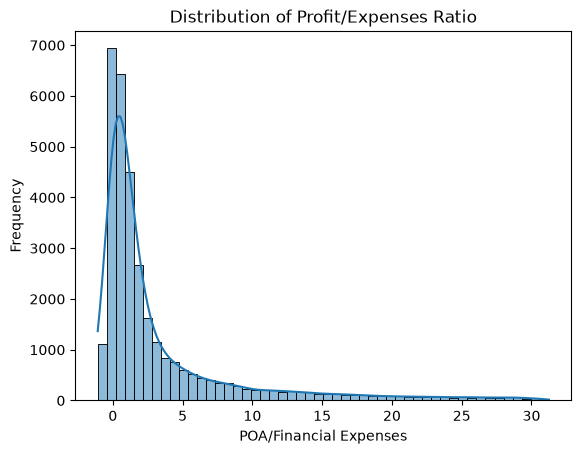

In [38]:
sns.histplot(data = df, x="X27", kde=True, bins=50)
plt.xlabel("POA/Financial Expenses")
plt.ylabel("Frequency")
plt.title("Distribution of Profit/Expenses Ratio");
plt.savefig("../reports/figures/POA_vs_fin_expenses.png", dpi=150)

# Splitting the data

In [39]:
# vertical split
X = df.drop(columns="Class")
y= df["Class"]


In [40]:
# Horizontal split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, shuffle=True)

To address the class imbalance in the target variable, we apply **Random Oversampling**, a widely used resampling technique that increases the number of instances in the minority class by randomly duplicating existing samples. Oversampling is one of the most effective preprocessing methods for handling imbalanced datasets, as it helps create a more balanced class distribution and can improve the performance of machine learning models on underrepresented classes.


In [41]:
from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)



In [42]:
y_train.value_counts()

Class
0    25385
1      625
Name: count, dtype: int64

In [43]:
X_train.shape

(26010, 65)

In [44]:
X_train_over.shape

(50770, 65)

In [45]:
y_train.value_counts(), y_train_over.value_counts()

(Class
 0    25385
 1      625
 Name: count, dtype: int64,
 Class
 0    25385
 1    25385
 Name: count, dtype: int64)

# Baseline

In [46]:
acc_baseline = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy is: {round(acc_baseline,2)}")

Baseline accuracy is: 0.98


In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

# fit the model on X_train, y_train
dtc_model = make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(random_state=42))
dtc_model.fit(X_train, y_train)

# fit the model on X_trai_over, y_train_over
dtc_model_over = make_pipeline(SimpleImputer(strategy="median"), DecisionTreeClassifier(random_state=42))
dtc_model_over.fit(X_train_over, y_train_over)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](65,)","['Year','X1','X2',...,'X62','X63','X64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,65
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`

In [48]:
for m in [dtc_model, dtc_model_over]:
    acc_train = m.score(X_train, y_train)
    acc_test = m.score(X_test, y_test)

    print(f"Training accuracy: {round(acc_train,2)}")
    print(f"Test accuracy: {round(acc_test,2)}")

Training accuracy: 1.0
Test accuracy: 0.97
Training accuracy: 1.0
Test accuracy: 0.97


### Effect of Oversampling on Model Performance

It is clear from the results that the model trained on the oversampled dataset achieves a higher test accuracy than the model trained on the original imbalanced dataset. This indicates that oversampling helped address the class imbalance, allowing the model to learn more representative decision boundaries for the minority class and improving its overall generalization performance on the test set.

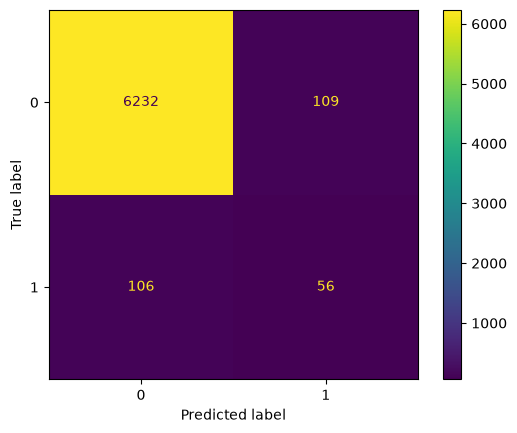

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# plot Confusion matrix
ConfusionMatrixDisplay.from_estimator(dtc_model_over, X_test, y_test)

In [53]:
# classification report
print(classification_report(y_test, dtc_model_over.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6341
           1       0.34      0.35      0.34       162

    accuracy                           0.97      6503
   macro avg       0.66      0.66      0.66      6503
weighted avg       0.97      0.97      0.97      6503



In [56]:
# confusion matrix
cm = confusion_matrix(y_test ,dtc_model_over.predict(X_test))
print(cm)

[[6232  109]
 [ 106   56]]


In [55]:
# exctracting the decision tree model depth
depth = dtc_model_over.named_steps["decisiontreeclassifier"].get_depth()
depth

47